In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

###`Q 1-3` Using the 'diamonds' dataset - sns.load_dataset('diamonds')
1. Create a violinplot of 'price' grouped by 'cut'.
2. Create regplot on `carat` vs `price`. and give hue on 'cut'
3. Create boxplot on 'color' and 'price'

In [3]:
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


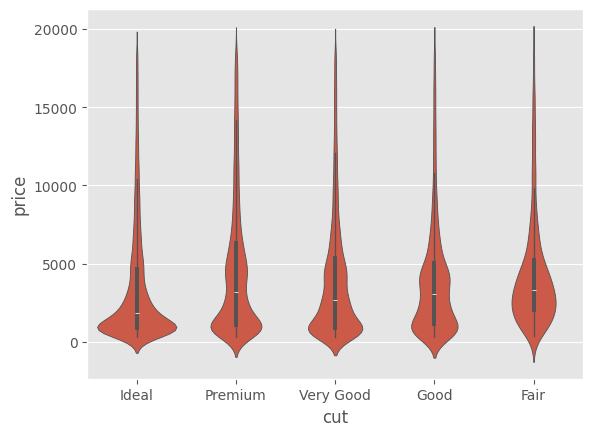

In [4]:
# Create a violin plot to show the price distribution for each cut category
sns.violinplot(
    data=diamonds,
    x='cut',
    y='price'
)

# Display the plot
plt.show()

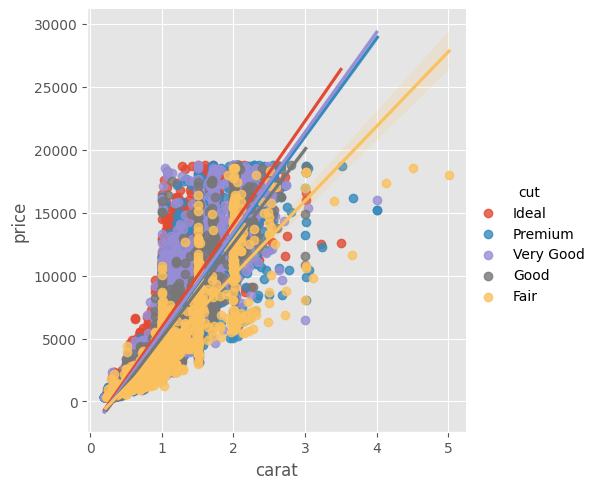

In [6]:
# Create a scatter plot with a regression line
sns.lmplot(
    data=diamonds,
    x='carat',
    y='price',
    hue='cut'
)

# Show the plot
plt.show()

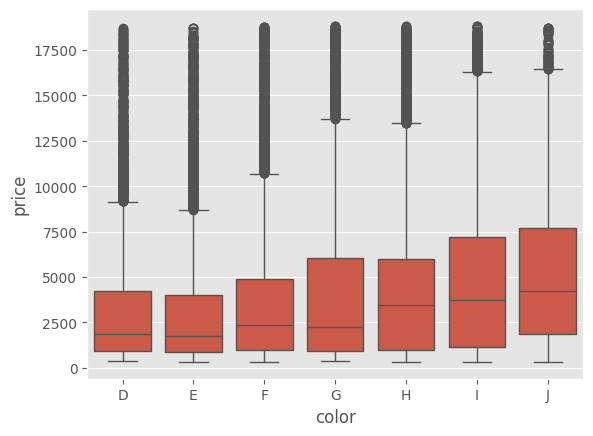

In [7]:
# Create a box plot to compare diamond prices by color
sns.boxplot(
    data=diamonds,
    x='color',
    y='price'
)

# Display the plot
plt.show()

###`Q 4` Using the 'Taxis' dataset - sns.load_dataset('taxis')
4.1. Create a categorical estimate plot of the totl fare - 'total' for each payment type - 'payment'.

4.2. Create a regression plot on time of ride  vs total fare. You will need to calculate ride time using pickup and dropoff column.

4.3 Give hue on payment type. and Another plot hue on taxi 'color'. Observe the plot.

In [9]:
taxis = sns.load_dataset('taxis')
taxis.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


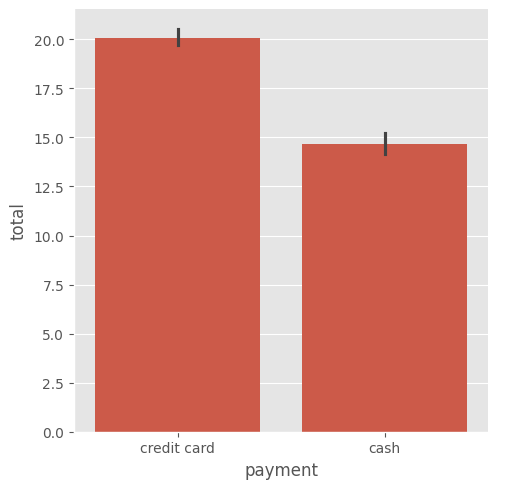

In [10]:
# Create a bar chart for average total by payment type
sns.catplot(
    data=taxis,
    x='payment',
    y='total',
    kind='bar'
)

# Display the plot
plt.show()

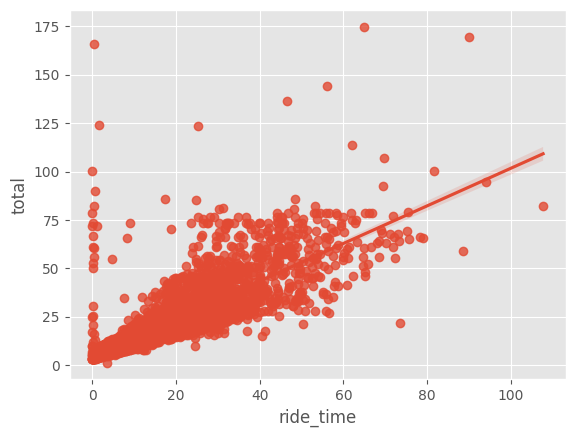

In [11]:
# Convert pickup and dropoff columns to datetime
taxis['pickup'] = pd.to_datetime(taxis['pickup'])
taxis['dropoff'] = pd.to_datetime(taxis['dropoff'])

# Calculate ride time in minutes
taxis['ride_time'] = (
    taxis['dropoff'] - taxis['pickup']
).dt.total_seconds() / 60

# Create a regression plot between ride time and total fare
sns.regplot(
    data=taxis,
    x='ride_time',
    y='total'
)

# Display the plot
plt.show()

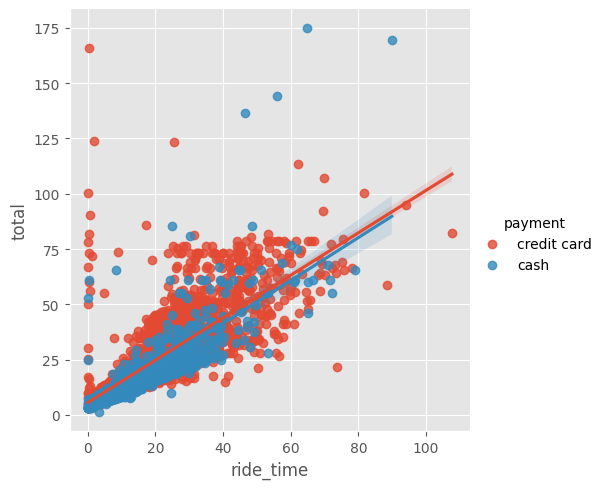

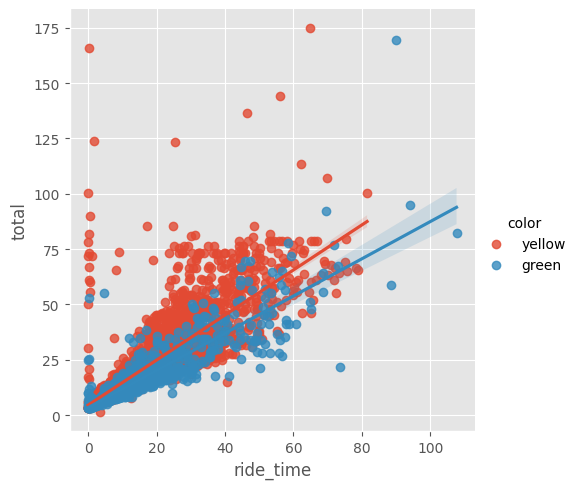

In [12]:
# Create a regression plot by payment method
sns.lmplot(
    data=taxis,
    x='ride_time',
    y='total',
    hue='payment'
)

# Create a regression plot by taxi color
sns.lmplot(
    data=taxis,
    x='ride_time',
    y='total',
    hue='color'
)

- Both yellow and green taxis show a positive relationship between ride time and total fare. As ride time increases, the total fare also increases. Yellow taxis have more rides in the dataset, but both taxi colors follow a similar trend.

## Problem 5-12:

### **`Problem 5:`** Draw a strip plot and swarm plot between "gender" and "bloodpressure" w.r.t "smoker" (use as hue parameter). Also add title to the charts.

In [13]:
df = pd.read_csv("/content/insurance_data.csv")
df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 16.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


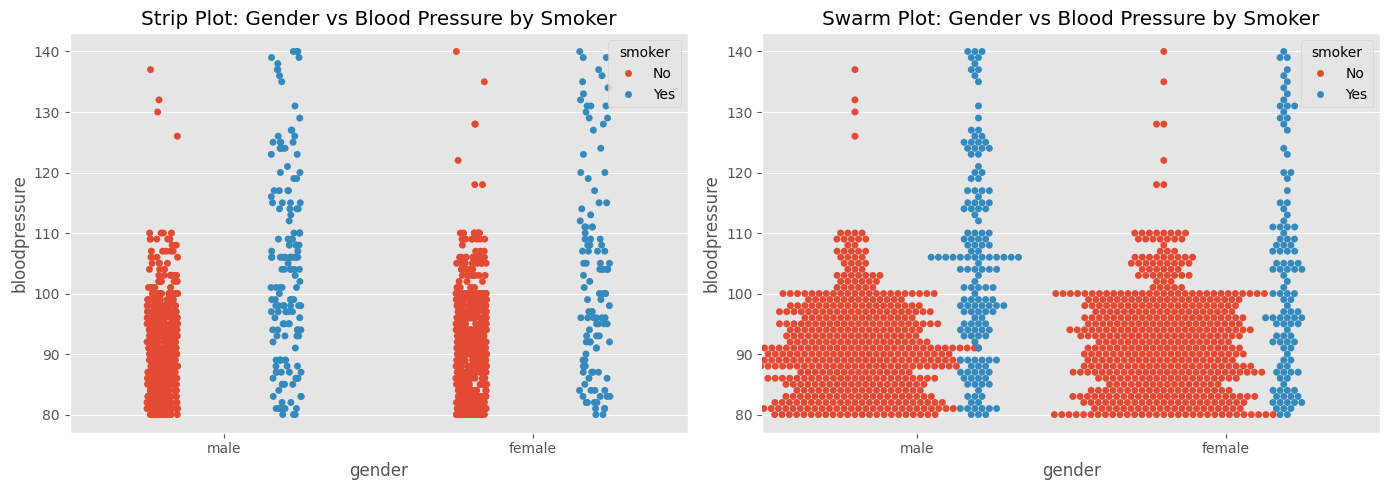

In [14]:
# Create a figure with two plots
plt.figure(figsize=(14, 5))

# Draw a strip plot
plt.subplot(1, 2, 1)
sns.stripplot(data=df, x="gender", y="bloodpressure", hue="smoker", dodge=True)
plt.title("Strip Plot: Gender vs Blood Pressure by Smoker")

# Draw a swarm plot
plt.subplot(1, 2, 2)
sns.swarmplot(data=df, x="gender", y="bloodpressure", hue="smoker", dodge=True)
plt.title("Swarm Plot: Gender vs Blood Pressure by Smoker")

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

### **`Problem 6:`** Draw a Box-plot and a Violin plot of which x-axis represents the "region" and the y-axis represents the "bmi". Also add extra information of the column "diabetic".

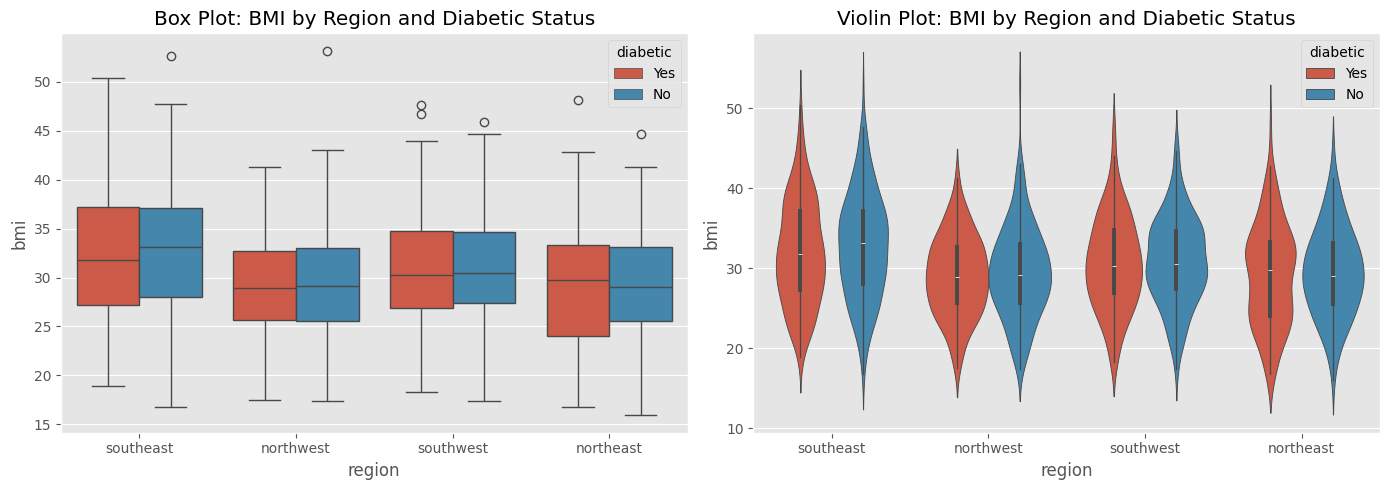

In [16]:
# Create a figure with two plots
plt.figure(figsize=(14, 5))

# Draw a box plot
plt.subplot(1, 2, 1)
sns.boxplot(
    data=df,
    x="region",
    y="bmi",
    hue="diabetic"
)
plt.title("Box Plot: BMI by Region and Diabetic Status")

# Draw a violin plot
plt.subplot(1, 2, 2)
sns.violinplot(
    data=df,
    x="region",
    y="bmi",
    hue="diabetic"
)
plt.title("Violin Plot: BMI by Region and Diabetic Status")

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

### **`Problem  7:`** Draw a bar plot and point plot of which x-axis represents the "gender" and y-axis represents "claim". Also add extra information about "smoker" column.

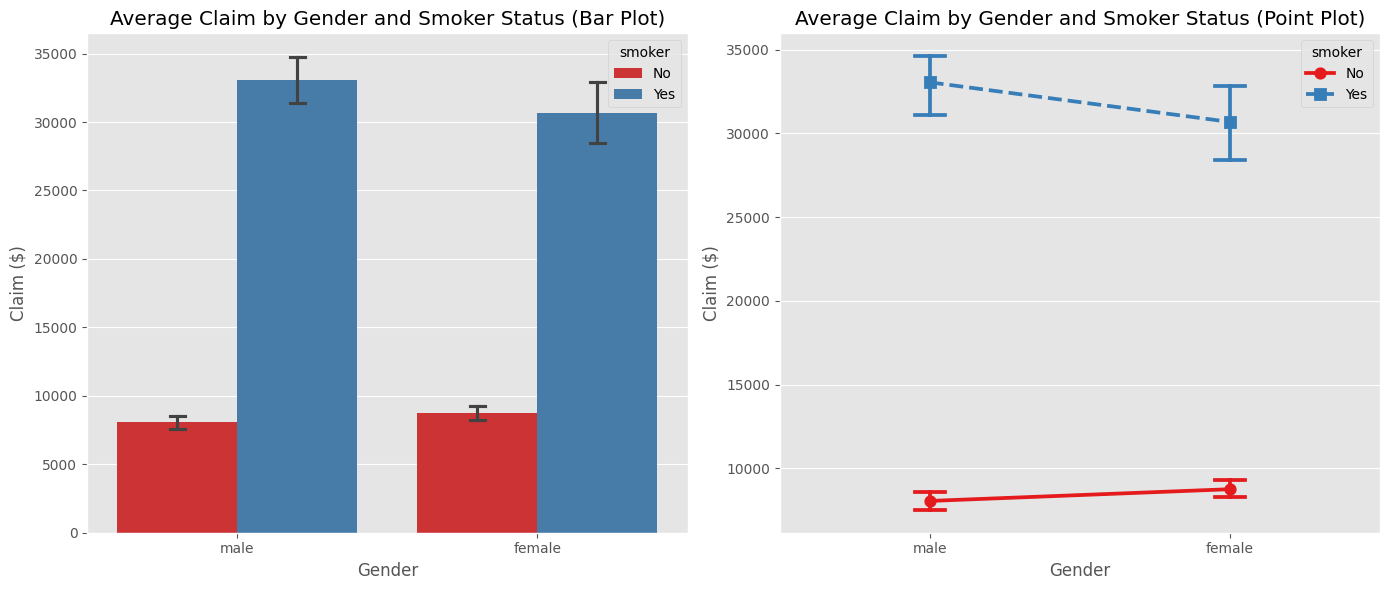

In [17]:
# Create two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Draw a bar plot
sns.barplot(
    data=df,
    x="gender",
    y="claim",
    hue="smoker",
    palette="Set1",
    ax=axes[0],
    capsize=0.1,
)
axes[0].set_title("Average Claim by Gender and Smoker Status (Bar Plot)")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Claim ($)")

# Draw a point plot
sns.pointplot(
    data=df,
    x="gender",
    y="claim",
    hue="smoker",
    palette="Set1",
    ax=axes[1],
    markers=["o", "s"],
    linestyles=["-", "--"],
    capsize=0.1,
)
axes[1].set_title("Average Claim by Gender and Smoker Status (Point Plot)")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Claim ($)")

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

### **`Problem 8:`** Draw a reg plot between "age" and "bmi" columns.

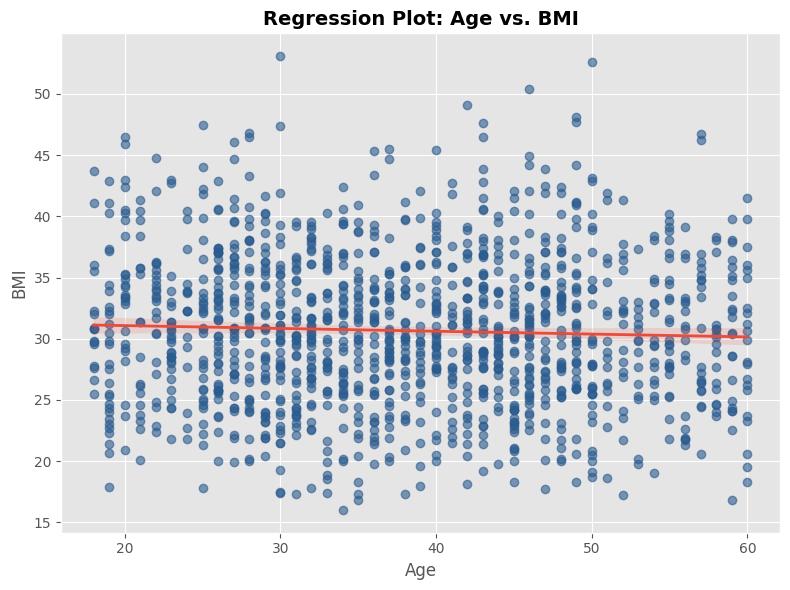

In [18]:
plt.figure(figsize=(8, 6))

# Draw regression plot
sns.regplot(
    data=df,
    x="age",
    y="bmi",
    scatter_kws={
        "alpha": 0.6,
        "color": "#2b5c8f",
    },  # Adjust marker transparency & color
    line_kws={"color": "#e74c3c", "linewidth": 2},  # Customize regression line
)

plt.title("Regression Plot: Age vs. BMI", fontsize=14, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("BMI", fontsize=12)

plt.tight_layout()
plt.show()

### **`Problem 9:`** Draw a pair plot of the insurance data. Use "gender" as hue parameter.

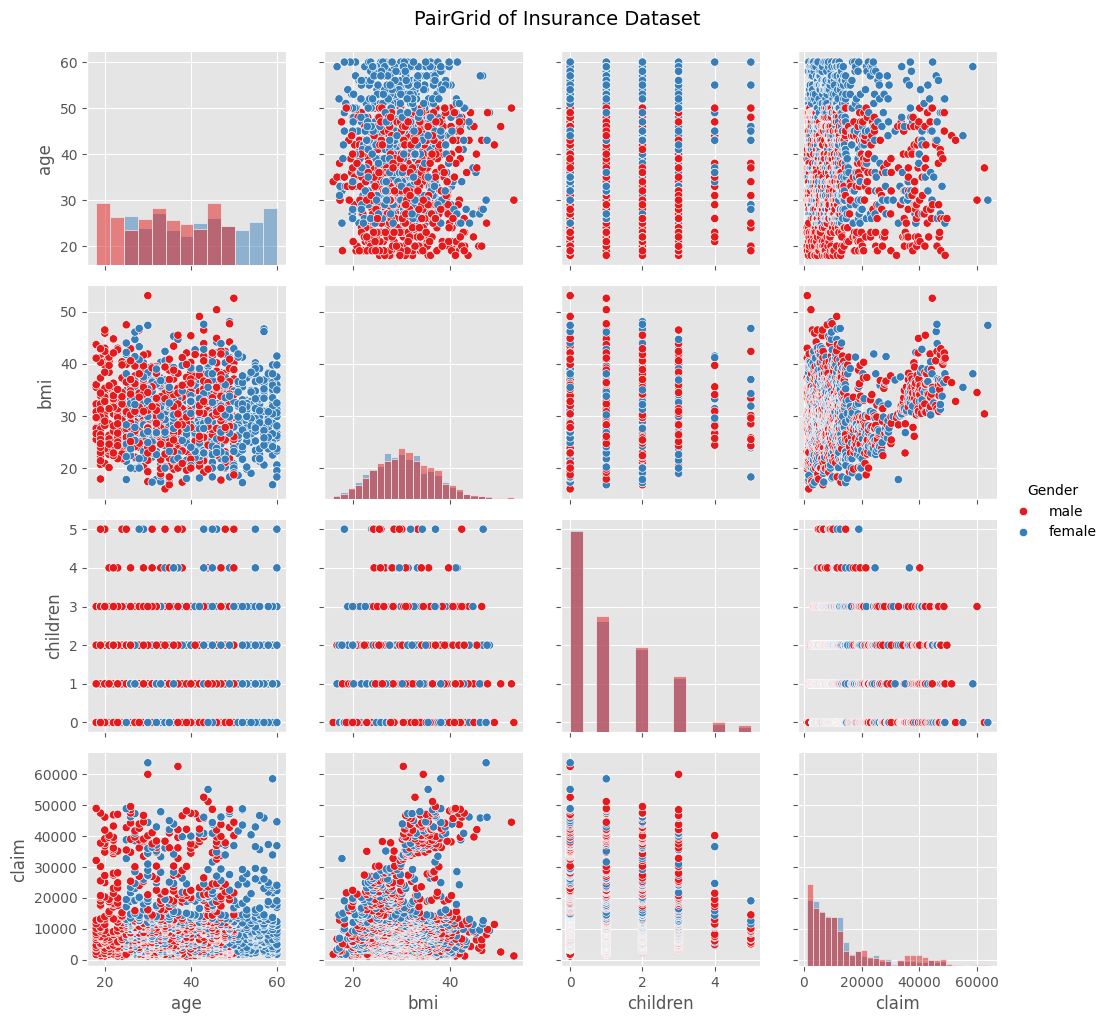

In [19]:
# Create a PairGrid for selected numeric columns
g = sns.PairGrid(
    df,
    vars=["age", "bmi", "children", "claim"],
    hue="gender",
    palette="Set1"
)

# Add histograms on the diagonal and scatter plots elsewhere
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

# Add legend and title
g.add_legend(title="Gender")
g.fig.suptitle("PairGrid of Insurance Dataset", y=1.02, fontsize=14)

# Display the plot
plt.show()

### **`Problem 10:`** Draw a pair grid of the insurance data and use "diabetic" column as a hue parameter. Also, make the diagonal plots as box-plot, upper parts as scatter plot and the lower parts as kde plot.

In [ ]:
df.head(2)

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51


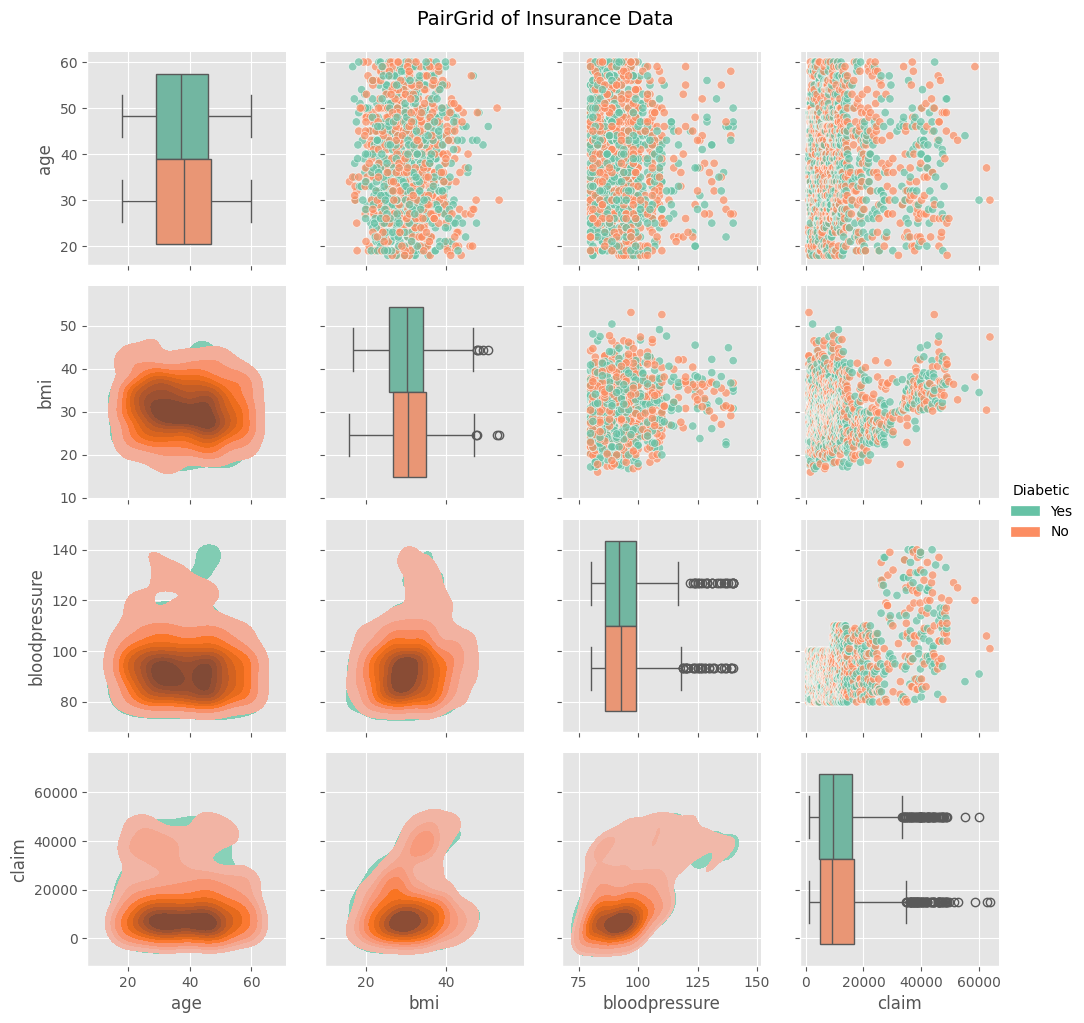

In [20]:
# Create a PairGrid with selected features
g = sns.PairGrid(
    data=df,
    vars=["age", "bmi", "bloodpressure", "claim"],
    hue="diabetic",
    palette="Set2"
)

# Add different plots to each section of the grid
g.map_diag(sns.boxplot)
g.map_upper(sns.scatterplot, alpha=0.7)
g.map_lower(sns.kdeplot, fill=True)

# Add legend and title
g.add_legend(title="Diabetic")
g.fig.suptitle(
    "PairGrid of Insurance Data",
    y=1.02,
    fontsize=14
)

# Display the plot
plt.show()

### **`Prolem 11:`** Draw a joint plot as scatter between "bloodpressure" and "bmi". Use "smoker" as hue parameter.

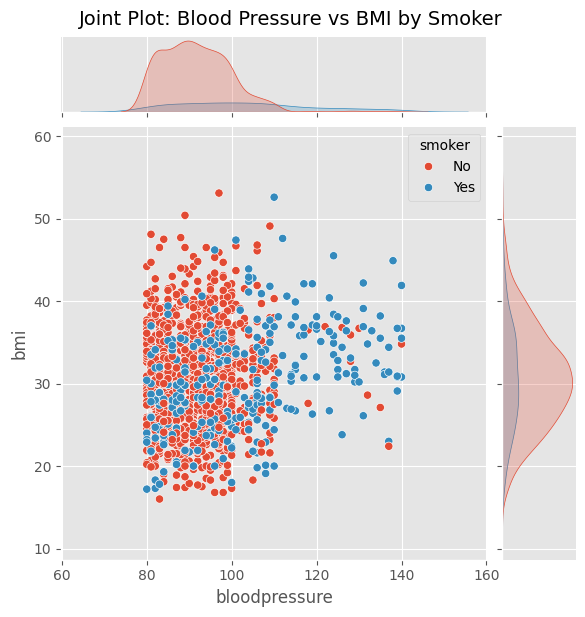

In [21]:
# Create a joint plot to compare blood pressure and BMI
g = sns.jointplot(
    data=df,
    x="bloodpressure",
    y="bmi",
    hue="smoker",
    kind="scatter",
    height=6
)

# Add a title
g.fig.suptitle(
    "Joint Plot: Blood Pressure vs BMI by Smoker",
    y=1.02,
    fontsize=14
)

# Display the plot
plt.show()

### **`Problem 12:`** Draw a joint grid of which x-axis represents "age" and y-axis represents "claim". Draw

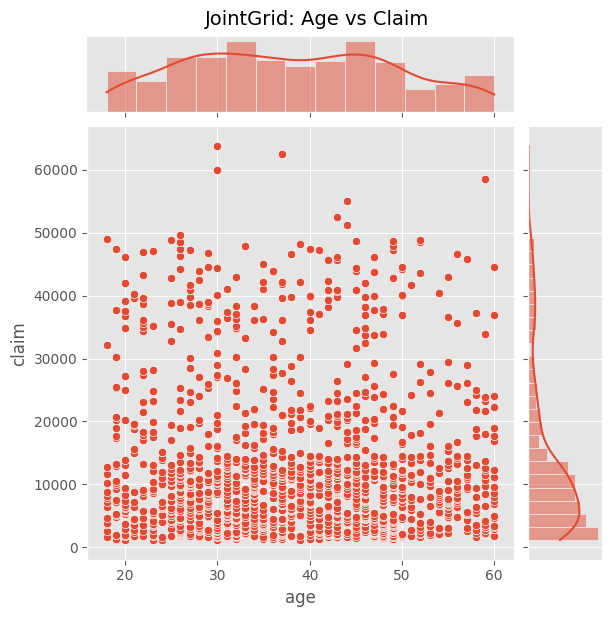

In [22]:
# Create a JointGrid for age and claim
g = sns.JointGrid(
    data=df,
    x="age",
    y="claim",
    height=6
)

# Draw the main scatter plot
g.plot_joint(sns.scatterplot)

# Add histograms on the margins
g.plot_marginals(sns.histplot, kde=True)

# Add a title
g.fig.suptitle(
    "JointGrid: Age vs Claim",
    y=1.02,
    fontsize=14
)

# Display the plot
plt.show()